# Paper Figures


Final figure generation for the ICML 2026 workshop submission.


In [1]:
from functools import cache
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from matplotlib.lines import Line2D
from wandb.apis.public.runs import Run

PROJECT = "graphcore/llama-mobile"
FIG_PATH = Path("/Users/lukar/Code/llama-mobile/figs")

DOWNSTREAM_TASKS = ["vqa", "chartqa", "docvqa", "ai2d"]
TASK_TITLES = {
    "vqa": "VQA",
    "chartqa": "ChartQA",
    "docvqa": "DocVQA",
    "ai2d": "AI2D",
}


# Global plot parameters
COLORS = {
    "int_qat": "#4C78A8",
    "int_direct": "#8FB1D4",
    "student_t": "#54A24B",
    "lloyd_max": "#F58518",
    "s3d8": "#E45756",
    "bf16": "0.35",
}
POINT_SIZE = 60
DIRECT_POINT_SIZE = 70
STAR_SIZE = 180
POINT_ALPHA = 0.95
EDGE_WIDTH = 0.6
LINE_WIDTH = 1.1
GRID_STYLE = {"axis": "y", "linestyle": ":", "linewidth": 0.6, "alpha": 0.45}

LABELS = {
    "int": r"$\mathtt{INT}$",
    "int_qat": r"$\mathtt{INT}$ + QAT",
    "int_direct": r"$\mathtt{INT}$ + direct cast",
    "bf16": r"$\mathtt{bfloat16}$ baseline",
    "s3d8": r"$\mathtt{S3D8}$",
}
FORMAT_PLOT_LABELS = {
    "INT": r"$\mathtt{INT}$",
    "student-t": r"$\mathtt{student{-}t}$",
    "lloyd-max": r"$\mathtt{lloyd{-}max}$",
    "S3D8": r"$\mathtt{S3D8}$",
}
FORMAT_LATEX_LABELS = {
    "INT": r"\texttt{INT}",
    "student-t": r"\texttt{student-t}",
    "lloyd-max": r"\texttt{lloyd-max}",
    "S3D8": r"\texttt{S3D8}",
}

sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


In [ ]:
# Set to True to save pdf figures to FIG_PATH
SAVE_FIGS = False

In [3]:
api = wandb.Api()


In [4]:
# Data helpers
def get_metric(task: str) -> str:
    from eval.vqa import TASKS

    metrics = TASKS[task].METRICS
    assert len(metrics) == 1
    return metrics[0]


def overall_metric(scores: list[float]) -> float:
    return sum(scores) / len(scores)


def get_field(x: Any, key: str) -> Any:
    if isinstance(x, dict):
        return x.get(key)
    return getattr(x, key, None)


def activation_fmt_name(fmt: Any) -> str:
    if fmt is None:
        return "bf16"

    fmt_type = get_field(fmt, "_type")
    element_format = get_field(fmt, "element_format")
    if fmt_type == "int" or (
        fmt_type == "linear" and get_field(element_format, "_type") == "int"
    ):
        return "int"
    return str(fmt)


@cache
def get_num_params(model_name: str) -> int:
    from accelerate import init_empty_weights
    from transformers import AutoConfig, MllamaForConditionalGeneration

    config = AutoConfig.from_pretrained(model_name)
    with init_empty_weights():
        model = MllamaForConditionalGeneration(config)
    return sum(p.numel() for p in model.parameters())


def get_prompt_type(train_data: list[dict[str, Any]]) -> str:
    assert len(train_data) == 1
    prompt_path = train_data[0]["path"].split("/")[-1]
    if prompt_path == "single-prompt-1280k":
        return "fixed"
    if prompt_path == "new-prompts-1280k":
        return "sampled"
    raise ValueError(f"unexpected prompt path: {prompt_path}")


def quantisation_format_name(fmt: dict[str, Any]) -> str:
    fmt_type = fmt["_type"]
    if fmt_type == "linear":
        element_format = fmt["element_format"]
        if element_format["_type"] == "lut":
            df = int(element_format["name"].split("[")[1].split("]")[0])
            return f"student-t [df={df}]"
        return element_format["_type"]

    if fmt_type == "fit_scaled":
        if fmt["element_family"] == "t":
            return "student-t [fit]"
        if fmt["element_family"] == "lloyd_max":
            return "lloyd-max [fit]"
        if fmt["element_family"] == "s3d8":
            return "s3d8"

    raise ValueError(f"unexpected format type: {fmt_type}")


def cleanup_run(run: Run) -> dict[str, Any]:
    config = run.config
    scores = {
        task: run.summary[f"downstream.{task}.{get_metric(task)}"]
        for task in DOWNSTREAM_TASKS
    }
    history = run.history()

    return {
        "name": run.name,
        "size": config["n_bits"] / (8 * 10**6),
        "bits_per_param": config["n_bits"] / get_num_params(config["model_name"]),
        "n_steps": config["training"]["n_steps"],
        "lr": config["training"]["optimiser"]["lr"],
        "prompt": get_prompt_type(config["data"]["train"]),
        "rotation": config["training"].get("rotate_text_residual"),
        "activation_fmt": activation_fmt_name(config["quantisation"].get("activation_fmt")),
        "fmt": quantisation_format_name(config["quantisation"]["fmt"]),
        "overall": overall_metric(list(scores.values())),
        "train_loss": history["train/loss"].tail(10).mean()
        if "train/loss" in history
        else None,
        "val_loss": run.summary.get("val/loss"),
        **scores,
    }


def load_runs(wandb_api: Any, config_name: str):
    return wandb_api.runs(
        PROJECT, filters={"config.name": config_name, "state": "finished"}
    )


def runs_dataframe(wandb_api: Any, config_name: str) -> pd.DataFrame:
    return (
        pd.DataFrame([cleanup_run(run) for run in load_runs(wandb_api, config_name)])
        .sort_values(["size", "overall"])
        .reset_index(drop=True)
    )


def labeled_runs_dataframe(
    wandb_api: Any,
    run_names: dict[str, str],
    label_col: str,
    *,
    n_steps: int | None = None,
) -> pd.DataFrame:
    frames = []
    for label, run_name in run_names.items():
        df = runs_dataframe(wandb_api, run_name)
        if n_steps is not None:
            df = df.loc[df["n_steps"] == n_steps]
        frames.append(df.assign(**{label_col: label}))
    return pd.concat(frames, ignore_index=True)


In [5]:
# Plot helpers
def finish_axis(ax, *, x_margin: float = 0.04, y_margin: float = 0.08) -> None:
    ax.grid(**GRID_STYLE)
    ax.margins(x=x_margin, y=y_margin)
    sns.despine(ax=ax)


def add_bits_axis(ax, size_to_bpp: float):
    secax = ax.secondary_xaxis(
        "top",
        functions=(lambda size: size * size_to_bpp, lambda bpp: bpp / size_to_bpp),
    )
    secax.set_xlabel("Bits per parameter", color="0.4", labelpad=5)
    secax.tick_params(axis="x", colors="0.45", labelsize=8, pad=2)
    secax.spines["top"].set_color("0.6")
    secax.spines["top"].set_alpha(0.5)
    return secax


def finish_size_axis(ax, size_to_bpp: float, **kwargs: Any) -> None:
    finish_axis(ax, **kwargs)
    add_bits_axis(ax, size_to_bpp)


def style_label(key: str, style: dict[str, Any]) -> str:
    return style.get("label", key)


def scatter_styled(
    ax,
    df: pd.DataFrame,
    x: str,
    y: str,
    style: dict[str, Any],
    *,
    label: str | None = None,
) -> None:
    ax.scatter(
        df[x],
        df[y],
        s=style.get("size", POINT_SIZE),
        marker=style.get("marker", "o"),
        color=style["color"],
        edgecolor=style.get("edgecolor", "white"),
        linewidth=style.get("linewidth", EDGE_WIDTH),
        alpha=POINT_ALPHA,
        zorder=style.get("zorder", 3),
        label=label,
    )


def line_styled(
    ax,
    df: pd.DataFrame,
    x: str,
    y: str,
    style: dict[str, Any],
    *,
    label: str | None = None,
) -> None:
    ax.plot(
        df[x],
        df[y],
        marker=style.get("marker", "o"),
        markersize=6,
        color=style["color"],
        linewidth=LINE_WIDTH,
        label=label,
    )


def scatter_groups(
    ax,
    df: pd.DataFrame,
    group_col: str,
    styles: dict[str, dict[str, Any]],
    x: str,
    y: str,
    *,
    label: bool = False,
) -> None:
    for key, style in styles.items():
        group_df = df.loc[df[group_col] == key]
        if not group_df.empty:
            scatter_styled(
                ax,
                group_df,
                x,
                y,
                style,
                label=style_label(key, style) if label else None,
            )


def line_groups(
    ax,
    df: pd.DataFrame,
    group_col: str,
    styles: dict[str, dict[str, Any]],
    x: str,
    y: str,
    *,
    label: bool = False,
) -> None:
    for key, style in styles.items():
        group_df = df.loc[df[group_col] == key]
        if not group_df.empty:
            line_styled(
                ax,
                group_df,
                x,
                y,
                style,
                label=style_label(key, style) if label else None,
            )


def plot_int_runs(ax, df: pd.DataFrame, y: str, *, direct: bool = False) -> None:
    if df.empty:
        return

    if direct:
        ax.scatter(
            df["size"],
            df[y],
            s=DIRECT_POINT_SIZE,
            marker="x",
            color=COLORS["int_direct"],
            linewidth=1.2,
            alpha=POINT_ALPHA,
            zorder=4,
        )
    else:
        scatter_styled(ax, df, "size", y, {"color": COLORS["int_qat"]})


def plot_bf16(ax, y: float) -> None:
    ax.axhline(y, linestyle="--", linewidth=LINE_WIDTH, color=COLORS["bf16"])


def plot_s3d8(ax, x: float, y: float) -> None:
    ax.scatter(
        [x],
        [y],
        marker="*",
        s=STAR_SIZE,
        color=COLORS["s3d8"],
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )


def style_handles(styles: dict[str, dict[str, Any]]) -> list[Line2D]:
    return [
        Line2D(
            [],
            [],
            marker=style.get("marker", "o"),
            linestyle="",
            markersize=6,
            markerfacecolor=style["color"],
            markeredgecolor=style.get("edgecolor", "white"),
            markeredgewidth=EDGE_WIDTH,
            label=style_label(key, style),
        )
        for key, style in styles.items()
    ]


def s3d8_handle() -> Line2D:
    return Line2D(
        [],
        [],
        marker="*",
        linestyle="",
        markersize=10,
        color=COLORS["s3d8"],
        markeredgecolor="black",
        label=LABELS["s3d8"],
    )


def model_legend_handles(*, compact: bool = False) -> list[Line2D]:
    handles = [
        Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=6,
            markerfacecolor=COLORS["int_qat"],
            markeredgecolor="white",
            markeredgewidth=EDGE_WIDTH,
            label=LABELS["int_qat"],
        ),
        Line2D(
            [],
            [],
            marker="x",
            linestyle="",
            markersize=7,
            color=COLORS["int_direct"],
            markeredgewidth=1.2,
            label=LABELS["int_direct"],
        ),
        s3d8_handle(),
        Line2D(
            [],
            [],
            linestyle="--",
            linewidth=LINE_WIDTH,
            color=COLORS["bf16"],
            label=LABELS["bf16"],
        ),
    ]
    if compact:
        return handles
    return [
        Line2D(
            [],
            [],
            marker="x",
            linestyle="",
            markersize=7,
            color=COLORS["int_direct"],
            markeredgewidth=1.2,
            label=LABELS["int_direct"],
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=6,
            markerfacecolor=COLORS["int_qat"],
            markeredgecolor="white",
            markeredgewidth=EDGE_WIDTH,
            label=LABELS["int_qat"],
        ),
        handles[-1],
    ]


def save_figure(fig, filename: str) -> None:
    if SAVE_FIGS:
        fig.savefig(FIG_PATH / filename, bbox_inches="tight")


### Main Figure

Compare $\mathtt{INT}$ block-scaled baselines against the selected $\mathtt{S3D8}$ run. Baseline points use $\mathtt{INT}$ activations, no rotations, and either direct casting or 2k-step QAT.

Runs:
- $\mathtt{INT}$ baseline: `int-baseline-22-04-26`
- $\mathtt{S3D8}$: `new-fmt-21-04-26`
- bfloat16 reference: `whole-fire-1607`

In [6]:
int_baseline_run = "int-baseline-22-04-26"
s3d8_run = "new-fmt-21-04-26"

baseline_df = runs_dataframe(api, int_baseline_run)
df_new = runs_dataframe(api, s3d8_run)

display(baseline_df.sort_values("size"))
display(df_new.sort_values(["size", "overall"]))


,name,size,bits_per_param,n_steps,lr,prompt,rotation,activation_fmt,fmt,overall,train_loss,val_loss,vqa,chartqa,docvqa,ai2d
0,balmy-donkey-1901,2840.533430,2.129690,2048,0.000015,sampled,False,int,int,0.000000,0.808444,1.248574,0.000000,0.000000,0.000000,0.000000
1,floral-waterfall-1907,2840.533430,2.129690,0,0.000015,sampled,False,int,int,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
2,noble-firefly-1900,3007.199270,2.254648,2048,0.000015,sampled,False,int,int,0.000000,0.737050,1.146234,0.000000,0.000000,0.000000,0.000000
3,denim-wave-1918,3007.199270,2.254648,0,0.000015,sampled,False,int,int,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
4,serene-sound-1903,3340.530950,2.504564,2048,0.000015,sampled,False,int,int,0.000163,0.524068,0.850739,0.000651,0.000000,0.000000,0.000000
5,solar-brook-1906,3340.530950,2.504564,0,0.000015,sampled,False,int,int,0.000326,NaN,NaN,0.001302,0.000000,0.000000,0.000000
6,easy-surf-1913,3620.479562,2.714455,0,0.000010,sampled,False,int,int,0.000895,NaN,NaN,0.003581,0.000000,0.000000,0.000000
7,happy-planet-1894,3620.479562,2.714455,2048,0.000010,sampled,False,int,int,0.347019,0.086261,0.145117,0.578776,0.302734,0.257542,0.249023
8,copper-plant-1915,3787.145402,2.839413,0,0.000010,sampled,False,int,int,0.001221,NaN,NaN,0.004883,0.000000,0.000000,0.000000
9,giddy-frog-1892,3787.145402,2.839413,2048,0.000010,sampled,False,int,int,0.360903,0.072365,0.120874,0.572917,0.453125,0.256439,0.161133


,name,size,bits_per_param,n_steps,lr,prompt,rotation,activation_fmt,fmt,overall,train_loss,val_loss,vqa,chartqa,docvqa,ai2d
0,brisk-serenity-1985,3568.774604,2.675689,0,0.000008,sampled,True,int,s3d8,0.000081,NaN,NaN,0.000326,0.000000,0.000000,0.000000
1,super-star-1930,3568.774604,2.675689,0,0.000008,sampled,False,int,s3d8,0.001383,NaN,NaN,0.005534,0.000000,0.000000,0.000000
2,toasty-jazz-1876,3568.774604,2.675689,2048,0.000008,sampled,True,bf16,s3d8,0.534913,0.036170,0.076068,0.675781,0.643555,0.613286,0.207031
3,twilight-plant-1984,3568.774604,2.675689,2048,0.000008,sampled,True,int,s3d8,0.598031,0.041253,0.080395,0.666341,0.638672,0.502150,0.584961
4,icy-shadow-1888,3568.774604,2.675689,4096,0.000008,sampled,False,int,s3d8,0.658020,0.034126,0.072855,0.678385,0.658203,0.698810,0.596680
5,proud-sponge-1878,3568.774604,2.675689,2048,0.000008,sampled,False,int,s3d8,0.661143,0.041032,0.077134,0.702148,0.648438,0.740275,0.553711
6,spring-rain-1874,3568.774604,2.675689,2048,0.000008,sampled,False,bf16,s3d8,0.689572,0.035088,0.061787,0.703776,0.680664,0.751777,0.622070
7,light-cloud-1873,3918.998892,2.938270,2048,0.000008,sampled,True,int,s3d8,0.618559,0.038982,0.078631,0.676758,0.631836,0.628531,0.537109
8,charmed-voice-1986,3918.998892,2.938270,2048,0.000008,sampled,False,int,s3d8,0.660875,0.040128,0.073240,0.689128,0.668945,0.751247,0.534180
9,devoted-valley-1880,4163.096140,3.121282,2048,0.000008,sampled,True,int,s3d8,0.545325,0.035914,0.087430,0.632161,0.686523,0.412418,0.450195


In [7]:
best_s3d8_run = "proud-sponge-1878"

best_run = df_new.loc[df_new["name"] == best_s3d8_run].iloc[0]
display(best_run)


name              proud-sponge-1878
size                    3568.774604
bits_per_param             2.675689
n_steps                        2048
lr                         0.000008
prompt                      sampled
rotation                      False
activation_fmt                  int
fmt                            s3d8
overall                    0.661143
train_loss                 0.041032
val_loss                   0.077134
vqa                        0.702148
chartqa                    0.648438
docvqa                     0.740275
ai2d                       0.553711
Name: 5, dtype: object

In [8]:
bf16_run_name = "whole-fire-1607"

bf16_run = api.runs(
    PROJECT,
    filters={"display_name": bf16_run_name, "state": "finished"},
)[0]

baseline = {
    task: bf16_run.summary[f"downstream.{task}.{get_metric(task)}"]
    for task in DOWNSTREAM_TASKS
}
baseline["overall"] = overall_metric(list(baseline.values()))
baseline_size = bf16_run.config["n_bits"] / (8 * 10**6)

display(baseline)
print(f"Original size: {baseline_size:.0f} MB")


{'vqa': 0.7542318105697632,
 'chartqa': 0.7470703125,
 'docvqa': 0.8444538116455078,
 'ai2d': 0.630859375,
 'overall': 0.7441538274288177}

Original size: 21340 MB


In [9]:
qat_df = baseline_df.loc[baseline_df["n_steps"] == 2048]
direct_cast_df = baseline_df.loc[baseline_df["n_steps"] == 0]
other_int_df = baseline_df.loc[~baseline_df["n_steps"].isin([0, 2048])]

our_size = best_run["size"]
our_perf = best_run["overall"]
our_task_scores = best_run[DOWNSTREAM_TASKS].to_dict()
our_loss_scores = best_run[["train_loss", "val_loss"]].to_dict()
size_to_bpp = baseline_df["bits_per_param"].iloc[0] / baseline_df["size"].iloc[0]


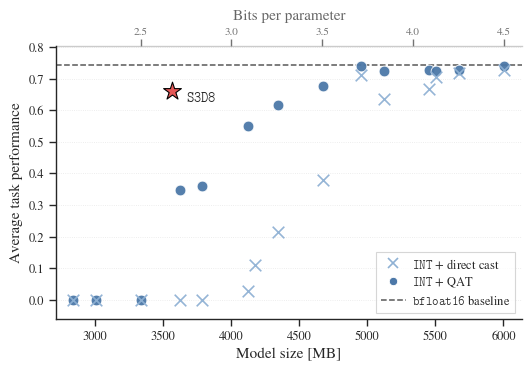

In [10]:
figsize = (5.2, 3.6)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

for df, direct in [(qat_df, False), (other_int_df, False), (direct_cast_df, True)]:
    plot_int_runs(ax, df, "overall", direct=direct)
plot_bf16(ax, baseline["overall"])
plot_s3d8(ax, our_size, our_perf)

ax.annotate(
    LABELS["s3d8"],
    xy=(our_size, our_perf),
    xytext=(10, -10),
    textcoords="offset points",
    fontsize=10,
    ha="left",
    va="bottom",
)
ax.set(
    # title="Overall Downstream Performance",
    xlabel="Model size [MB]",
    ylabel="Average task performance",
)
finish_size_axis(ax, size_to_bpp)

ax.legend(
    handles=model_legend_handles(),
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig1.pdf")
plt.show()


### Downstream Tasks


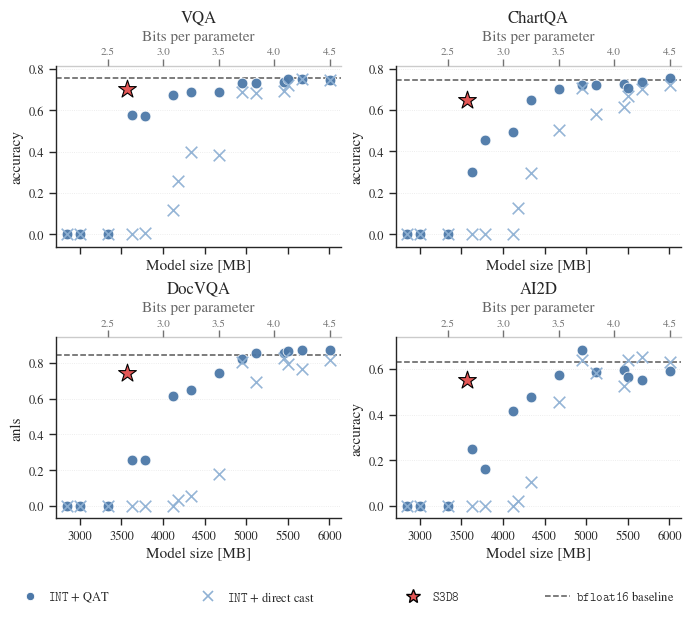

In [11]:
figsize = (6.8, 5.6)
fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, constrained_layout=True)

for ax, task in zip(axes.flatten(), DOWNSTREAM_TASKS):
    for df, direct in [(qat_df, False), (other_int_df, False), (direct_cast_df, True)]:
        plot_int_runs(ax, df, task, direct=direct)
    plot_bf16(ax, baseline[task])
    plot_s3d8(ax, our_size, our_task_scores[task])

    ax.set(title=TASK_TITLES[task], xlabel="Model size [MB]", ylabel=get_metric(task))
    finish_size_axis(ax, size_to_bpp)

fig.legend(
    handles=model_legend_handles(compact=True),
    loc="lower center",
    ncol=4,
    mode="expand",
    frameon=False,
    bbox_to_anchor=(0.0, -0.09, 1.0, 0.08),
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_tasks.pdf")
plt.show()


### Loss Curves


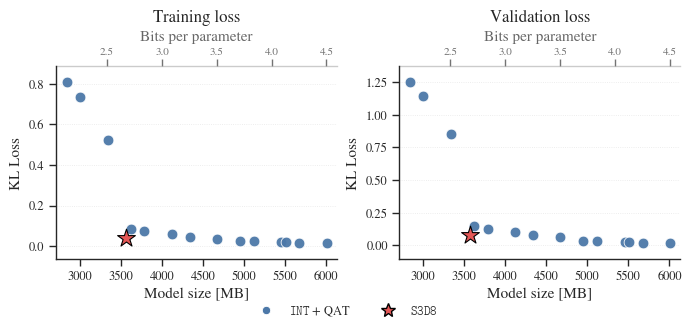

In [12]:
loss_specs = [("train_loss", "Training loss"), ("val_loss", "Validation loss")]
figsize = (6.8, 3.0)
fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

for ax, (key, title) in zip(axes, loss_specs):
    plot_int_runs(ax, baseline_df.dropna(subset=[key]), key)
    plot_s3d8(ax, our_size, our_loss_scores[key])

    ax.set(title=title, xlabel="Model size [MB]", ylabel="KL Loss")
    finish_size_axis(ax, size_to_bpp, y_margin=0.10)

fig.legend(
    handles=model_legend_handles(compact=True)[::2],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

# save_figure(fig, "fig_loss.pdf")
plt.show()


### Prompt Sampling vs. Fixed Prompt


Compare sampled prompts against a fixed `Describe this image` prompt. Both settings use the same 75% instruction-template mix, $\mathtt{INT3}$ weights with 64-value block scales, and steps in `[256, 512, 1024, 2048]`.

Run: `prompt-comparison-24-04-26`


In [13]:
prompt_run = "prompt-comparison-24-04-26"
max_num_steps = 4096
prompt_styles = {
    "sampled": {"color": COLORS["int_qat"], "marker": "o", "label": "Sampled"},
    "fixed": {"color": COLORS["s3d8"], "marker": "s", "label": "Fixed"},
}

prompt_df = runs_dataframe(api, prompt_run)
plot_prompt_df = prompt_df.loc[prompt_df["n_steps"] <= max_num_steps]
prompt_steps = sorted(plot_prompt_df["n_steps"].unique())

display(prompt_df)


,name,size,bits_per_param,n_steps,lr,prompt,rotation,activation_fmt,fmt,overall,train_loss,val_loss,vqa,chartqa,docvqa,ai2d
0,ethereal-water-1982,4340.52599,3.25431,1024,0.000008,fixed,False,int,int,0.213155,0.049401,0.109742,0.344401,0.366211,0.090249,0.051758
1,solar-wildflower-1978,4340.52599,3.25431,256,0.000008,fixed,False,int,int,0.215733,0.076681,0.142208,0.398763,0.170898,0.183895,0.109375
2,rare-bee-1981,4340.52599,3.25431,512,0.000008,fixed,False,int,int,0.254703,0.061844,0.122064,0.414388,0.228516,0.172784,0.203125
3,dandy-paper-1978,4340.52599,3.25431,2048,0.000008,fixed,False,int,int,0.335963,0.039983,0.088989,0.437500,0.549805,0.098734,0.257812
4,colorful-surf-2007,4340.52599,3.25431,8192,0.000008,fixed,False,int,int,0.360603,0.028250,0.064148,0.406901,0.541016,0.110705,0.383789
5,electric-sea-1991,4340.52599,3.25431,4096,0.000008,fixed,False,int,int,0.378364,0.033112,0.077648,0.455729,0.547852,0.102647,0.407227
6,royal-wave-1983,4340.52599,3.25431,512,0.000008,sampled,False,int,int,0.402382,0.066791,0.098409,0.651693,0.581055,0.263499,0.113281
7,neat-deluge-2006,4340.52599,3.25431,6144,0.000008,fixed,False,int,int,0.409186,0.029969,0.068285,0.437174,0.554688,0.197617,0.447266
8,vibrant-cloud-1976,4340.52599,3.25431,256,0.000008,sampled,False,int,int,0.439071,0.084920,0.117811,0.639974,0.542969,0.477637,0.095703
9,worthy-violet-1980,4340.52599,3.25431,1024,0.000008,sampled,False,int,int,0.500261,0.050930,0.080393,0.670573,0.684570,0.410549,0.235352


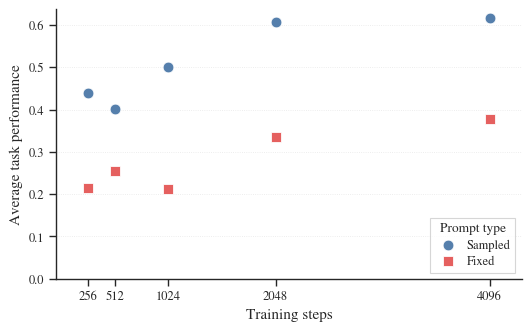

In [14]:
figsize = (5.2, 3.2)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

scatter_groups(ax, plot_prompt_df, "prompt", prompt_styles, "n_steps", "overall", label=True)
ax.set(
    # title="Prompt Sampling vs. Fixed Prompt",
    xlabel="Training steps",
    ylabel="Average task performance",
    xticks=prompt_steps,
)
ax.set_ylim(bottom=0)
finish_axis(ax, x_margin=0.08)

ax.legend(
    title="Prompt type",
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_prompt_overall.pdf")
plt.show()


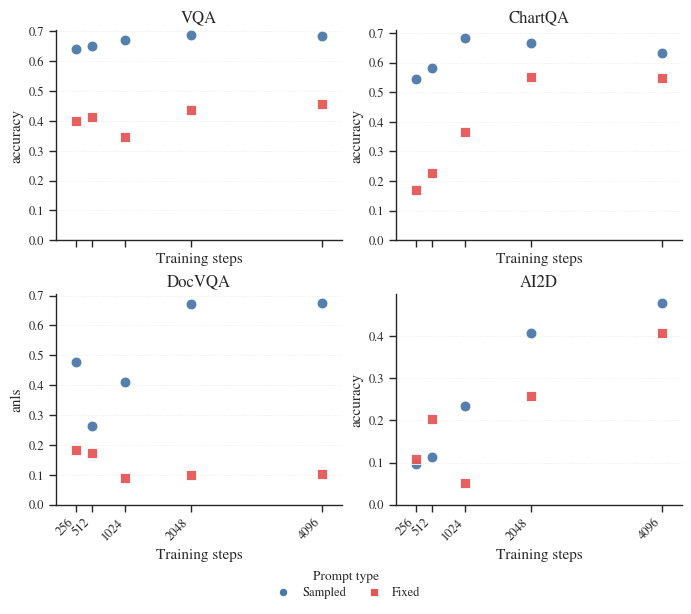

In [15]:
figsize = (6.8, 5.6)
fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, constrained_layout=True)

for ax, task in zip(axes.flatten(), DOWNSTREAM_TASKS):
    scatter_groups(ax, plot_prompt_df, "prompt", prompt_styles, "n_steps", task)
    ax.set(
        title=TASK_TITLES[task],
        xlabel="Training steps",
        ylabel=get_metric(task),
        xticks=prompt_steps,
    )
    ax.set_ylim(bottom=0)
    finish_axis(ax, x_margin=0.08)
    ax.tick_params(axis="x", labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

fig.legend(
    handles=style_handles(prompt_styles),
    title="Prompt type",
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    columnspacing=1.2,
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_prompt_tasks.pdf")
plt.show()


### Learning Rate Sweep


Plot 2048-step runs from `lr-sweep-17-03-26` and `lr-sweep-27-04-26` against optimiser learning rate.


In [16]:
lr_sweep_runs = {
    "without activation quantisation": "lr-sweep-17-03-26",
    "with activation quantisation": "lr-sweep-27-04-26",
}
lr_styles = {
    "without activation quantisation": {"color": COLORS["int_direct"], "marker": "s"},
    "with activation quantisation": {"color": COLORS["int_qat"], "marker": "o"},
}

lr_df = labeled_runs_dataframe(api, lr_sweep_runs, "activation_quantisation", n_steps=2048)
lr_df = lr_df.sort_values(["activation_quantisation", "lr"])
lr_ticks = sorted(lr_df["lr"].unique())
lr_tick_labels = [rf"$2^{{{round(np.log2(lr))}}}$" for lr in lr_ticks]

display(lr_df[["activation_quantisation", "name", "lr", "overall", "train_loss", "val_loss"]])


,activation_quantisation,name,lr,overall,train_loss,val_loss
6,with activation quantisation,grateful-pine-1999,0.000002,0.529248,0.053270,0.069772
7,with activation quantisation,morning-valley-1996,0.000004,0.571440,0.046678,0.070196
8,with activation quantisation,bright-jazz-1997,0.000008,0.589491,0.042474,0.073908
9,with activation quantisation,usual-sound-1995,0.000015,0.596799,0.042148,0.081507
5,with activation quantisation,decent-sponge-1998,0.000031,0.497811,0.048871,0.105915
1,without activation quantisation,neat-snowflake-2015,0.000002,0.508260,0.045528,0.062716
3,without activation quantisation,vibrant-star-1727,0.000004,0.643431,0.043338,0.055303
4,without activation quantisation,sleek-pyramid-1725,0.000008,0.653210,0.039730,0.053646
2,without activation quantisation,sunny-music-1729,0.000015,0.568615,0.040569,0.057950
0,without activation quantisation,summer-sound-2014,0.000031,0.506433,0.044740,0.083346


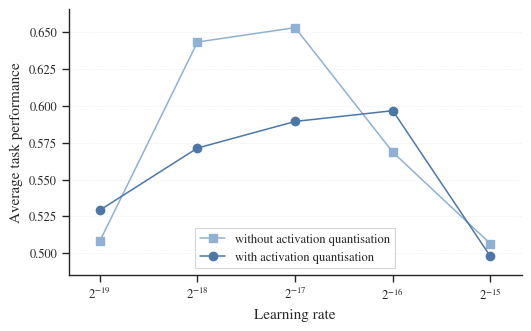

In [17]:
figsize = (5.2, 3.2)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

line_groups(ax, lr_df, "activation_quantisation", lr_styles, "lr", "overall", label=True)
ax.set_xscale("log", base=2)
ax.set(
    # title="Learning Rate Sweep",
    xlabel="Learning rate",
    ylabel="Average task performance",
    xticks=lr_ticks,
    xticklabels=lr_tick_labels,
)
finish_axis(ax, x_margin=0.08)
ax.legend(frameon=True, fancybox=False, edgecolor="0.8")

# save_figure(fig, "fig_lr_overall.pdf")
plt.show()


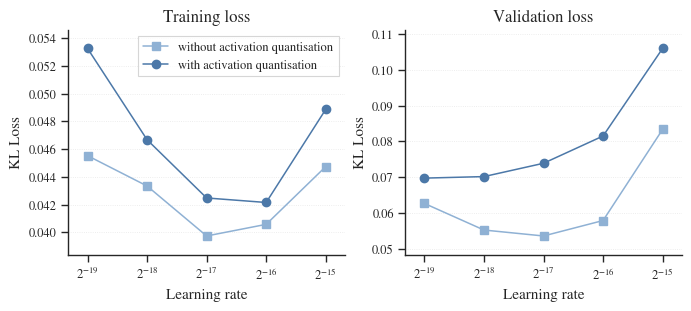

In [18]:
loss_specs = [("train_loss", "Training loss"), ("val_loss", "Validation loss")]
figsize = (6.8, 3.0)
fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

for ax, (key, title) in zip(axes, loss_specs):
    line_groups(ax, lr_df, "activation_quantisation", lr_styles, "lr", key, label=True)
    ax.set_xscale("log", base=2)
    ax.set(
        title=title,
        xlabel="Learning rate",
        ylabel="KL Loss",
        xticks=lr_ticks,
        xticklabels=lr_tick_labels,
    )
    finish_axis(ax, x_margin=0.08, y_margin=0.10)

axes[0].legend(frameon=True, fancybox=False, edgecolor="0.8")

# save_figure(fig, "fig_lr_loss.pdf")
plt.show()


### Format Comparison


Compare 2048-step QAT points from $\mathtt{INT}$, $\mathtt{student{-}t}$, and scalar $\mathtt{lloyd{-}max}$ baselines against the selected $\mathtt{S3D8}$ run.


In [19]:
format_runs = {
    "INT": "int-baseline-22-04-26",
    "student-t": "student-t-baseline-22-04-26",
    "lloyd-max": "lloyd-max-baseline-22-04-26",
}
format_styles = {
    "INT": {"color": COLORS["int_qat"], "marker": "o", "label": FORMAT_PLOT_LABELS["INT"]},
    "student-t": {"color": COLORS["student_t"], "marker": "D", "label": FORMAT_PLOT_LABELS["student-t"]},
    "lloyd-max": {"color": COLORS["lloyd_max"], "marker": "^", "label": FORMAT_PLOT_LABELS["lloyd-max"]},
}

format_df = labeled_runs_dataframe(api, format_runs, "format", n_steps=2048)
format_df = format_df.sort_values(["format", "size", "overall"])

format_display_df = format_df.assign(format=format_df["format"].replace(FORMAT_LATEX_LABELS))
display(format_display_df[["format", "name", "size", "bits_per_param", "overall", *DOWNSTREAM_TASKS]])


,format,name,size,bits_per_param,overall,vqa,chartqa,docvqa,ai2d
0,\texttt{INT},balmy-donkey-1901,2840.533430,2.129690,0.000000,0.000000,0.000000,0.000000,0.000000
1,\texttt{INT},noble-firefly-1900,3007.199270,2.254648,0.000000,0.000000,0.000000,0.000000,0.000000
2,\texttt{INT},serene-sound-1903,3340.530950,2.504564,0.000163,0.000651,0.000000,0.000000,0.000000
3,\texttt{INT},happy-planet-1894,3620.479562,2.714455,0.347019,0.578776,0.302734,0.257542,0.249023
4,\texttt{INT},giddy-frog-1892,3787.145402,2.839413,0.360903,0.572917,0.453125,0.256439,0.161133
5,\texttt{INT},giddy-river-1898,4120.477082,3.089328,0.549059,0.673503,0.493164,0.615505,0.414062
6,\texttt{INT},warm-grass-1899,4340.525990,3.254310,0.615241,0.688477,0.647461,0.647489,0.477539
7,\texttt{INT},brisk-donkey-1893,4673.857670,3.504226,0.677013,0.689779,0.704102,0.741906,0.572266
8,\texttt{INT},glad-terrain-1897,4953.806282,3.714117,0.739595,0.731120,0.722656,0.821009,0.683594
9,\texttt{INT},smooth-dew-1890,5120.472122,3.839075,0.723212,0.732096,0.721680,0.854110,0.584961


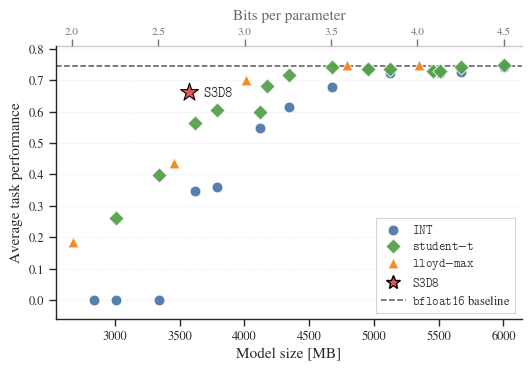

In [20]:
figsize = (5.2, 3.6)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

scatter_groups(ax, format_df, "format", format_styles, "size", "overall", label=True)
plot_bf16(ax, baseline["overall"])
plot_s3d8(ax, our_size, our_perf)

ax.annotate(
    LABELS["s3d8"],
    xy=(our_size, our_perf),
    xytext=(10, -5),
    textcoords="offset points",
    fontsize=10,
    ha="left",
    va="bottom",
)
ax.set(
    # title="Format Comparison",
    xlabel="Model size [MB]",
    ylabel="Average task performance",
)
finish_size_axis(ax, size_to_bpp)

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=[*handles, s3d8_handle(), model_legend_handles(compact=True)[-1]],
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_format_overall.pdf")
plt.show()


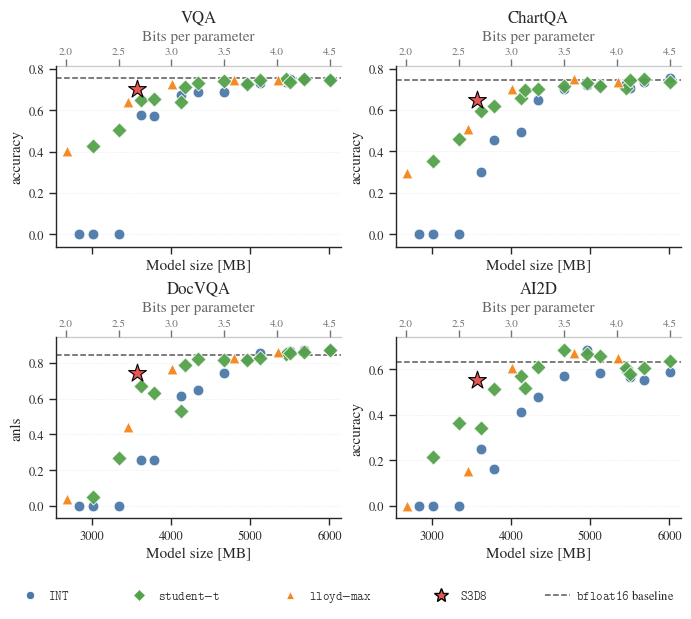

In [21]:
figsize = (6.8, 5.6)
fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, constrained_layout=True)

for ax, task in zip(axes.flatten(), DOWNSTREAM_TASKS):
    scatter_groups(ax, format_df, "format", format_styles, "size", task)
    plot_bf16(ax, baseline[task])
    plot_s3d8(ax, our_size, our_task_scores[task])

    ax.set(title=TASK_TITLES[task], xlabel="Model size [MB]", ylabel=get_metric(task))
    finish_size_axis(ax, size_to_bpp)

fig.legend(
    handles=[*style_handles(format_styles), s3d8_handle(), model_legend_handles(compact=True)[-1]],
    loc="lower center",
    ncol=5,
    mode="expand",
    frameon=False,
    bbox_to_anchor=(0.0, -0.09, 1.0, 0.08),
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_format_tasks.pdf")
plt.show()


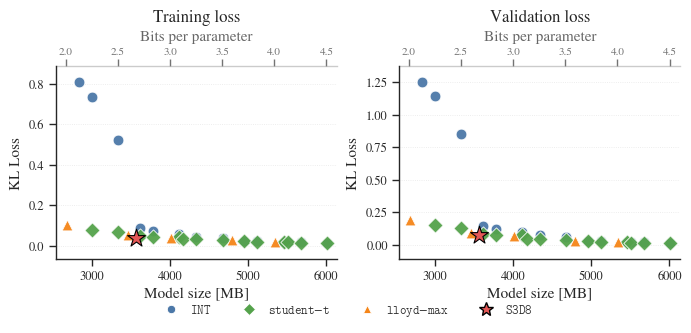

In [22]:
loss_specs = [("train_loss", "Training loss"), ("val_loss", "Validation loss")]
figsize = (6.8, 3.0)
fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

for ax, (key, title) in zip(axes, loss_specs):
    scatter_groups(ax, format_df.dropna(subset=[key]), "format", format_styles, "size", key)
    plot_s3d8(ax, our_size, our_loss_scores[key])

    ax.set(title=title, xlabel="Model size [MB]", ylabel="KL Loss")
    finish_size_axis(ax, size_to_bpp, y_margin=0.10)

fig.legend(
    handles=[*style_handles(format_styles), s3d8_handle()],
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    labelspacing=0.35,
    handletextpad=0.5,
)

# save_figure(fig, "fig_format_loss.pdf")
plt.show()


In [23]:
summary_columns = [
    "format",
    # "name",
    "size",
    "bits_per_param",
    "overall",
    *DOWNSTREAM_TASKS,
    # "train_loss",
    # "val_loss",
]
closest_format_df = (
    format_df.assign(size_delta=(format_df["size"] - our_size).abs())
    .sort_values(["format", "size_delta", "overall"], ascending=[True, True, False])
    .groupby("format", as_index=False)
    .head(1)
)
s3d8_summary = best_run.to_frame().T.assign(format="S3D8")
bf16_summary = pd.DataFrame(
    [
        {
            "format": "bfloat16",
            "name": bf16_run.name,
            "size": baseline_size,
            "bits_per_param": bf16_run.config["n_bits"]
            / get_num_params(bf16_run.config["model_name"]),
            "overall": baseline["overall"],
            **{task: baseline[task] for task in DOWNSTREAM_TASKS},
            "train_loss": None,
            "val_loss": bf16_run.summary.get("val/loss"),
        }
    ]
)

format_summary_df = pd.concat(
    [s3d8_summary, bf16_summary, closest_format_df],
    ignore_index=True,
).loc[:, summary_columns]

format_summary_df = format_summary_df.sort_values(
    "format",
    key=lambda s: s.map(
        {"S3D8": 1, "bfloat16": 0, "INT": 2, "student-t": 3, "lloyd-max": 4}
    ),
)
format_summary_display_df = format_summary_df.copy()
format_summary_display_df["size"] = pd.to_numeric(format_summary_display_df["size"]).round().astype(int)
format_summary_display_df["bits_per_param"] = pd.to_numeric(
    format_summary_display_df["bits_per_param"]
).round(2)
metric_columns = ["overall", *DOWNSTREAM_TASKS]
format_summary_display_df[metric_columns] = format_summary_display_df[metric_columns].apply(
    pd.to_numeric
).round(3)
format_summary_display_df["format"] = format_summary_display_df["format"].replace(
    FORMAT_LATEX_LABELS
)
display(format_summary_display_df)


,format,size,bits_per_param,overall,vqa,chartqa,docvqa,ai2d
1,bfloat16,21340,16.00,0.744,0.754,0.747,0.844,0.631
0,\texttt{S3D8},3569,2.68,0.661,0.702,0.648,0.740,0.554
2,\texttt{INT},3620,2.71,0.347,0.579,0.303,0.258,0.249
4,\texttt{student-t},3620,2.71,0.565,0.647,0.598,0.670,0.344
3,\texttt{lloyd-max},3459,2.59,0.436,0.638,0.510,0.444,0.151


In [24]:
paper_table_df = format_summary_display_df.rename(
    columns={
        "format": "Format",
        "size": "Size [MB]",
        "bits_per_param": "Bits",
        "overall": "Avg.",
        "vqa": "VQA",
        "chartqa": "ChartQA",
        "docvqa": "DocVQA",
        "ai2d": "AI2D",
    }
)

print(
    paper_table_df.to_latex(
        index=False,
        escape=False,
        column_format="lrrrrrrr",
    )
)


\begin{tabular}{lrrrrrrr}
\toprule
Format & Size [MB] & Bits & Avg. & VQA & ChartQA & DocVQA & AI2D \\
\midrule
bfloat16 & 21340 & 16.000000 & 0.744000 & 0.754000 & 0.747000 & 0.844000 & 0.631000 \\
\texttt{S3D8} & 3569 & 2.680000 & 0.661000 & 0.702000 & 0.648000 & 0.740000 & 0.554000 \\
\texttt{INT} & 3620 & 2.710000 & 0.347000 & 0.579000 & 0.303000 & 0.258000 & 0.249000 \\
\texttt{student-t} & 3620 & 2.710000 & 0.565000 & 0.647000 & 0.598000 & 0.670000 & 0.344000 \\
\texttt{lloyd-max} & 3459 & 2.590000 & 0.436000 & 0.638000 & 0.510000 & 0.444000 & 0.151000 \\
\bottomrule
\end{tabular}



### Loss and Task Performance Correlation


Compare train and validation loss against average downstream task performance for the 2048-step format comparison sweep points.


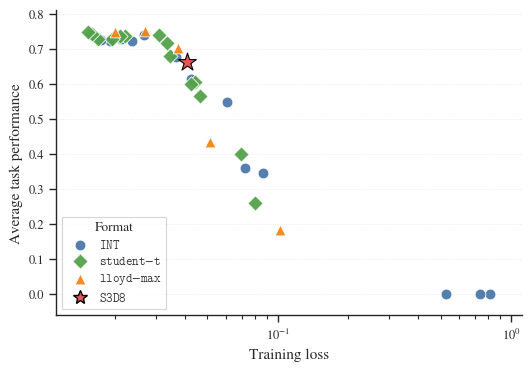

In [25]:
figsize = (5.2, 3.6)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

loss_perf_df = format_df.dropna(subset=["train_loss", "overall"])
scatter_groups(
    ax,
    loss_perf_df,
    "format",
    format_styles,
    "train_loss",
    "overall",
    label=True,
)
plot_s3d8(ax, our_loss_scores["train_loss"], our_perf)
ax.set_xscale("log")
ax.set(
    xlabel="Training loss",
    ylabel="Average task performance",
)
finish_axis(ax, x_margin=0.08, y_margin=0.08)
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=[*handles, s3d8_handle()],
    title="Format",
    loc="lower left",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

save_figure(fig, "fig_task_vs_train_loss.pdf")
plt.show()


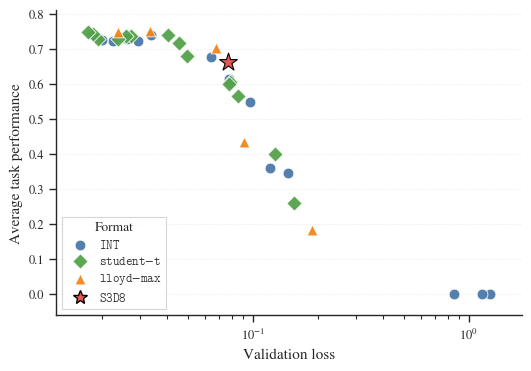

In [26]:
figsize = (5.2, 3.6)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

loss_perf_df = format_df.dropna(subset=["val_loss", "overall"])
scatter_groups(
    ax,
    loss_perf_df,
    "format",
    format_styles,
    "val_loss",
    "overall",
    label=True,
)
plot_s3d8(ax, our_loss_scores["val_loss"], our_perf)
ax.set_xscale("log")
ax.set(
    xlabel="Validation loss",
    ylabel="Average task performance",
)
finish_axis(ax, x_margin=0.08, y_margin=0.08)
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=[*handles, s3d8_handle()],
    title="Format",
    loc="lower left",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

# save_figure(fig, "fig_task_vs_val_loss.pdf")
plt.show()


Spearman rank correlations for the same plotted points, including $\mathtt{S3D8}$.


In [27]:
def spearman_corr(df: pd.DataFrame, x: str, y: str) -> float:
    corr_df = df.dropna(subset=[x, y])
    return corr_df[x].rank().corr(corr_df[y].rank())


loss_perf_with_s3d8_df = pd.concat(
    [
        format_df[["format", "train_loss", "val_loss", "overall"]],
        pd.DataFrame(
            [
                {
                    "format": "S3D8",
                    "train_loss": our_loss_scores["train_loss"],
                    "val_loss": our_loss_scores["val_loss"],
                    "overall": our_perf,
                }
            ]
        ),
    ],
    ignore_index=True,
)

spearman_df = pd.DataFrame(
    [
        {
            "x": "Training loss",
            "y": "Average task performance",
            "n": len(loss_perf_with_s3d8_df.dropna(subset=["train_loss", "overall"])),
            "spearman_rho": spearman_corr(
                loss_perf_with_s3d8_df, "train_loss", "overall"
            ),
        },
        {
            "x": "Validation loss",
            "y": "Average task performance",
            "n": len(loss_perf_with_s3d8_df.dropna(subset=["val_loss", "overall"])),
            "spearman_rho": spearman_corr(loss_perf_with_s3d8_df, "val_loss", "overall"),
        },
    ]
)

display(spearman_df.assign(spearman_rho=spearman_df["spearman_rho"].round(3)))


,x,y,n,spearman_rho
0,Training loss,Average task performance,34,-0.907
1,Validation loss,Average task performance,34,-0.909


### Abblation: keeping layers in higher precision


In [28]:
def higher_precision_layers(overrides: dict[str, Any] | None) -> str:
    keys = set((overrides or {}).keys())
    has_output = any(key.startswith("language_model.lm_head") for key in keys)
    has_vision = any(
        key.startswith("vision_model") or key.startswith("multi_modal_projector")
        for key in keys
    )

    if has_output and has_vision:
        return "LLM output + vision encoder"
    if has_output:
        return "LLM output"
    if has_vision:
        return "Vision encoder"
    return "None"


def cleanup_ablation_run(run: Run) -> dict[str, Any]:
    config = run.config
    scores = {
        task: run.summary[f"downstream.{task}.{get_metric(task)}"]
        for task in DOWNSTREAM_TASKS
    }
    history = run.history()

    return {
        "higher_precision_layers": higher_precision_layers(
            config["quantisation"].get("overrides")
        ),
        "n_steps": config["training"]["n_steps"],
        "rotation": config["training"].get("rotate_text_residual"),
        "activation_fmt": activation_fmt_name(config["quantisation"].get("activation_fmt")),
        "size": config["n_bits"] / (8 * 10**6),
        "bits_per_param": config["n_bits"] / get_num_params(config["model_name"]),
        "overall": overall_metric(list(scores.values())),
        "train_loss": history["train/loss"].tail(10).mean()
        if "train/loss" in history
        else None,
        **scores,
    }


ablation_order = [
    "None",
    "LLM output",
    "Vision encoder",
    "LLM output + vision encoder",
]
show_task_columns = True
performance_columns = ["overall", *(DOWNSTREAM_TASKS if show_task_columns else [])]
ablation_columns = [
    "higher_precision_layers",
    "size",
    "bits_per_param",
    *performance_columns,
    "train_loss",
]

ablation_df = pd.DataFrame(
    [cleanup_ablation_run(run) for run in load_runs(api, s3d8_run)]
)
ablation_df = ablation_df.loc[
    (ablation_df["n_steps"] == 2048)
    & (ablation_df["rotation"] == False)
    & (ablation_df["activation_fmt"] == "int")
    & ablation_df["higher_precision_layers"].isin(ablation_order)
].copy()
ablation_df["higher_precision_layers"] = pd.Categorical(
    ablation_df["higher_precision_layers"], categories=ablation_order, ordered=True
)
ablation_df = ablation_df.sort_values("higher_precision_layers")
if len(ablation_df) != 4:
    raise ValueError(f"Expected 4 ablation rows, found {len(ablation_df)}")

ablation_display_df = ablation_df.loc[:, ablation_columns].rename(
    columns={
        "higher_precision_layers": "INT8 layer",
        "size": "Size [MB]",
        "bits_per_param": "Bits",
        "overall": "Avg.",
        "vqa": "VQA",
        "chartqa": "ChartQA",
        "docvqa": "DocVQA",
        "ai2d": "AI2D",
        "train_loss": "Train loss",
    }
)
metric_columns = ["Avg.", *(TASK_TITLES[task] for task in DOWNSTREAM_TASKS if show_task_columns), "Train loss"]
ablation_display_df["Size [MB]"] = (
    pd.to_numeric(ablation_display_df["Size [MB]"]).round().astype(int)
)
ablation_display_df["Bits"] = pd.to_numeric(ablation_display_df["Bits"]).round(2)
ablation_display_df[metric_columns] = ablation_display_df[metric_columns].apply(
    pd.to_numeric
).round(3)
latex_formatters = {
    "Size [MB]": "{:.0f}".format,
    "Bits": "{:.2f}".format,
    **{column: "{:.3f}".format for column in metric_columns},
}

display(ablation_display_df)
print(
    ablation_display_df.to_latex(
        index=False,
        escape=False,
        formatters=latex_formatters,
        column_format="l" + "r" * (len(ablation_display_df.columns) - 1),
    )
)


,INT8 layer,Size [MB],Bits,Avg.,VQA,ChartQA,DocVQA,AI2D,Train loss
3,None,3569,2.68,0.661,0.702,0.648,0.740,0.554,0.041
10,LLM output,3919,2.94,0.661,0.689,0.669,0.751,0.534,0.040
11,Vision encoder,4163,3.12,0.666,0.693,0.721,0.737,0.514,0.035
12,LLM output + vision encoder,4513,3.38,0.667,0.734,0.695,0.807,0.431,0.034


\begin{tabular}{lrrrrrrrr}
\toprule
INT8 layer & Size [MB] & Bits & Avg. & VQA & ChartQA & DocVQA & AI2D & Train loss \\
\midrule
None & 3569 & 2.68 & 0.661 & 0.702 & 0.648 & 0.740 & 0.554 & 0.041 \\
LLM output & 3919 & 2.94 & 0.661 & 0.689 & 0.669 & 0.751 & 0.534 & 0.040 \\
Vision encoder & 4163 & 3.12 & 0.666 & 0.693 & 0.721 & 0.737 & 0.514 & 0.035 \\
LLM output + vision encoder & 4513 & 3.38 & 0.667 & 0.734 & 0.695 & 0.807 & 0.431 & 0.034 \\
\bottomrule
\end{tabular}

